<a href="https://www.kaggle.com/code/sonawanelalitsunil/soundsync-ai-your-personalized-dj-ml-100?scriptVersionId=225828474" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ai-powered-music-recommendation-system/music_sentiment_dataset.csv


## 🎯 Overview
**An AI-powered music recommendation system is designed to suggest songs tailored to users' preferences, moods, and listening habits. Using advanced machine learning algorithms and deep learning techniques, the system analyzes user interactions, song metadata, and audio features to provide highly personalized recommendations.**



#### 🏗️ How It Works

Data Collection & Preprocessing

User listening history, preferences, and ratings

Song metadata (artist, genre, mood, tempo, energy, etc.)

Audio features (BPM, danceability, acousticness, etc.)

#### Feature Engineering

Transforming categorical data (e.g., genre) into numerical form using Label Encoding

Normalizing audio-based features for better model performance

#### Model Selection

Collaborative Filtering: Recommends songs based on users with similar listening patterns

Content-Based Filtering: Analyzes song features to recommend similar tracks

Hybrid Approach: Combines collaborative and content-based filtering for optimal recommendations

#### AI & Machine Learning Algorithms

KNN (K-Nearest Neighbors): Finds songs closest to a user’s taste
Matrix Factorization (SVD, ALS): Identifies hidden patterns in song preferences
Deep Learning (Neural Networks): Uses deep embeddings for personalized recommendations
Reinforcement Learning: Continuously improves based on user feedback
User Interface & Experience

Seamless integration into music platforms like Spotify, Apple Music, YouTube Music
Real-time song suggestions based on mood & activity
Voice-based recommendations (e.g., “Play a relaxing song”)
Interactive feedback loop (users can like/dislike recommendations to refine accuracy)

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/ai-powered-music-recommendation-system/music_sentiment_dataset.csv')

In [4]:
df.head()

,User_ID,User_Text,Sentiment_Label,Recommended_Song_ID,Song_Name,Artist,Genre,Tempo (BPM),Mood,Energy,Danceability
0,U1,Way ball purpose public experience recently re...,Sad,S1,Someone Like You,Adele,Pop,67,Melancholic,Low,Low
1,U2,Save officer two myself a.,Happy,S2,Happy,Pharrell Williams,Pop,160,Joyful,High,High
2,U3,Decade ahead everyone environment themselves a...,Relaxed,S3,Clair de Lune,Debussy,Classical,60,Soothing,Low,Low
3,U4,Best change letter citizen try ask quality pro...,Happy,S4,Happy,Pharrell Williams,Pop,160,Joyful,High,High
4,U5,Worker player chance kind actually.,Happy,S5,Happy,Pharrell Williams,Pop,160,Joyful,High,High


In [5]:
df.tail()

,User_ID,User_Text,Sentiment_Label,Recommended_Song_ID,Song_Name,Artist,Genre,Tempo (BPM),Mood,Energy,Danceability
995,U996,Where carry sit argue through street.,Relaxed,S996,Clair de Lune,Debussy,Classical,60,Soothing,Low,Low
996,U997,Agreement state up hope free manage outside.,Happy,S997,Happy,Pharrell Williams,Pop,160,Joyful,High,High
997,U998,Particular else challenge ball.,Relaxed,S998,Clair de Lune,Debussy,Classical,60,Soothing,Low,Low
998,U999,Much level someone.,Relaxed,S999,Weightless,Marconi Union,Ambient,50,Calm,Low,Low
999,U1000,Appear the two score.,Relaxed,S1000,Weightless,Marconi Union,Ambient,50,Calm,Low,Low


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   User_ID              1000 non-null   object
 1   User_Text            1000 non-null   object
 2   Sentiment_Label      1000 non-null   object
 3   Recommended_Song_ID  1000 non-null   object
 4   Song_Name            1000 non-null   object
 5   Artist               1000 non-null   object
 6   Genre                1000 non-null   object
 7   Tempo (BPM)          1000 non-null   int64 
 8   Mood                 1000 non-null   object
 9   Energy               1000 non-null   object
 10  Danceability         1000 non-null   object
dtypes: int64(1), object(10)
memory usage: 86.1+ KB


In [7]:
df.describe()

,Tempo (BPM)
count,1000.00000
mean,97.76000
std,36.74701
min,50.00000
25%,67.00000
50%,109.00000
75%,130.00000
max,160.00000


In [8]:
df.corr

<bound method DataFrame.corr of     User_ID                                          User_Text  \
0        U1  Way ball purpose public experience recently re...   
1        U2                         Save officer two myself a.   
2        U3  Decade ahead everyone environment themselves a...   
3        U4  Best change letter citizen try ask quality pro...   
4        U5                Worker player chance kind actually.   
..      ...                                                ...   
995    U996              Where carry sit argue through street.   
996    U997       Agreement state up hope free manage outside.   
997    U998                    Particular else challenge ball.   
998    U999                                Much level someone.   
999   U1000                              Appear the two score.   

    Sentiment_Label Recommended_Song_ID         Song_Name             Artist  \
0               Sad                  S1  Someone Like You              Adele   
1             H

In [9]:
df.isnull().sum()

User_ID                0
User_Text              0
Sentiment_Label        0
Recommended_Song_ID    0
Song_Name              0
Artist                 0
Genre                  0
Tempo (BPM)            0
Mood                   0
Energy                 0
Danceability           0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.dtypes

User_ID                object
User_Text              object
Sentiment_Label        object
Recommended_Song_ID    object
Song_Name              object
Artist                 object
Genre                  object
Tempo (BPM)             int64
Mood                   object
Energy                 object
Danceability           object
dtype: object

In [12]:
df.columns

Index(['User_ID', 'User_Text', 'Sentiment_Label', 'Recommended_Song_ID',
       'Song_Name', 'Artist', 'Genre', 'Tempo (BPM)', 'Mood', 'Energy',
       'Danceability'],
      dtype='object')

## Data visualizations

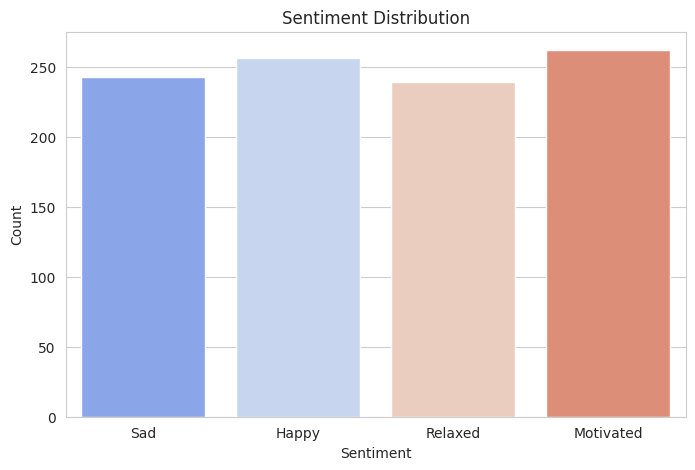

In [13]:
# Set Seaborn style
sns.set_style("whitegrid")

# 1. Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Sentiment_Label", palette="coolwarm")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


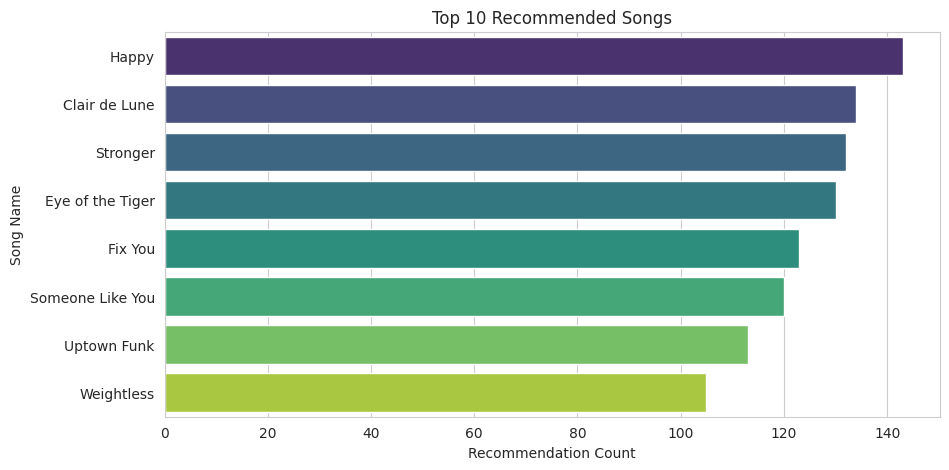

In [14]:
# 2. Top 10 Recommended Songs
plt.figure(figsize=(10, 5))
top_songs = df["Song_Name"].value_counts().head(10)
sns.barplot(x=top_songs.values, y=top_songs.index, palette="viridis")
plt.title("Top 10 Recommended Songs")
plt.xlabel("Recommendation Count")
plt.ylabel("Song Name")
plt.show()

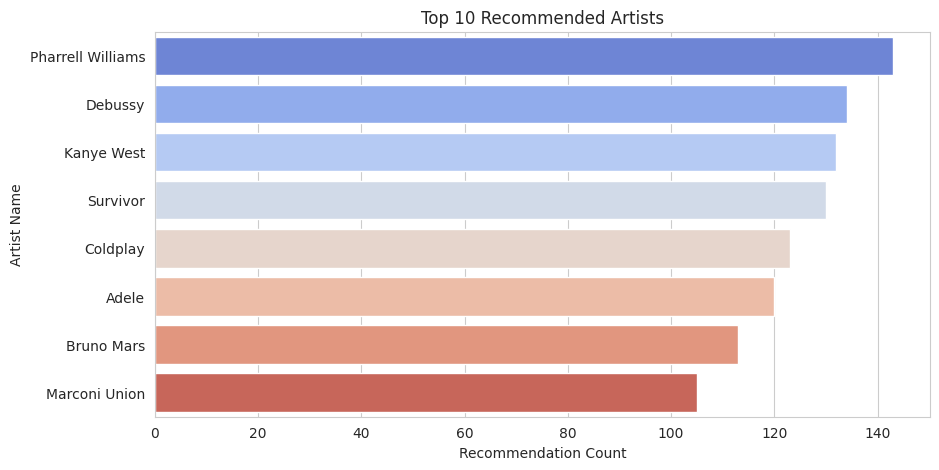

In [15]:
# 3. Top 10 Artists
plt.figure(figsize=(10, 5))
top_artists = df["Artist"].value_counts().head(10)
sns.barplot(x=top_artists.values, y=top_artists.index, palette="coolwarm")
plt.title("Top 10 Recommended Artists")
plt.xlabel("Recommendation Count")
plt.ylabel("Artist Name")
plt.show()

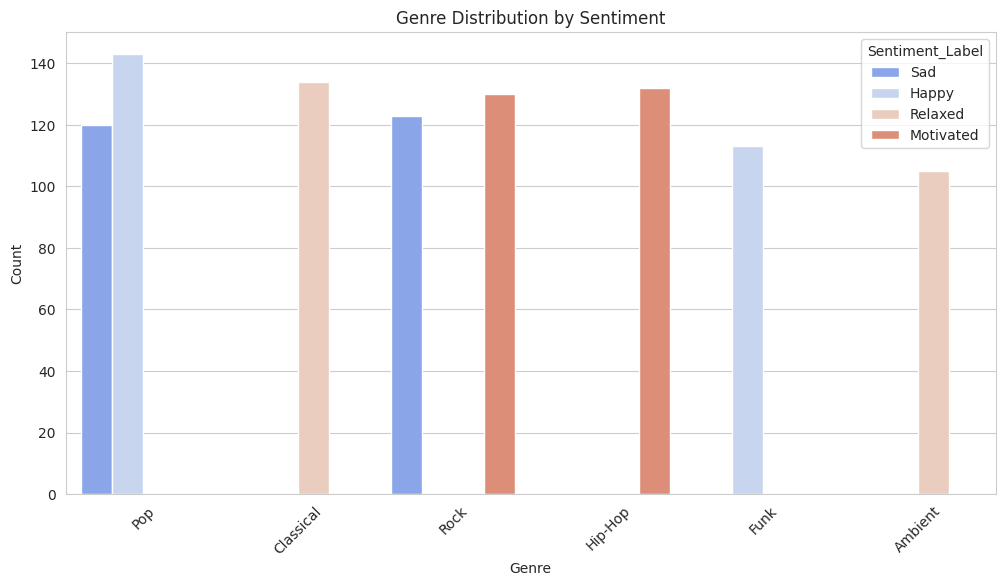

In [16]:
# 4. Genre vs Sentiment
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="Genre", hue="Sentiment_Label", palette="coolwarm")
plt.title("Genre Distribution by Sentiment")
plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

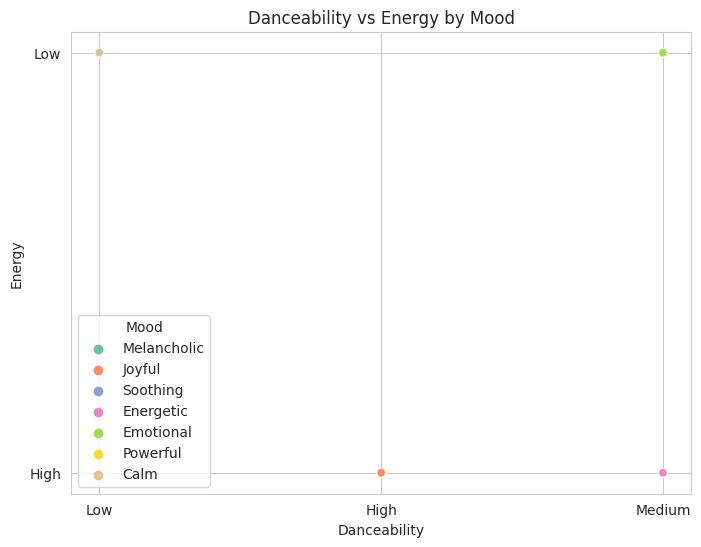

In [17]:
# 5. Energy vs Danceability (Scatter Plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Danceability", y="Energy", hue="Mood", palette="Set2", alpha=0.7)
plt.title("Danceability vs Energy by Mood")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.show()

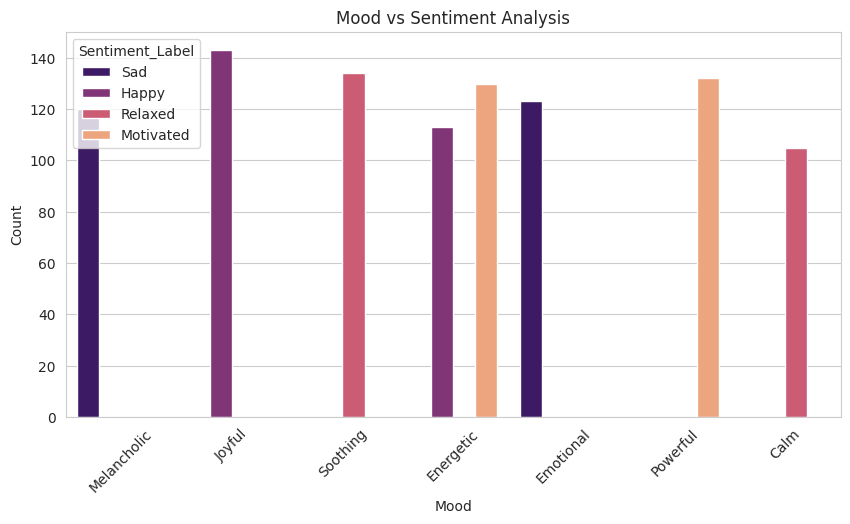

In [18]:
# 6. Mood vs Sentiment
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Mood", hue="Sentiment_Label", palette="magma")
plt.title("Mood vs Sentiment Analysis")
plt.xticks(rotation=45)
plt.xlabel("Mood")
plt.ylabel("Count")
plt.show()

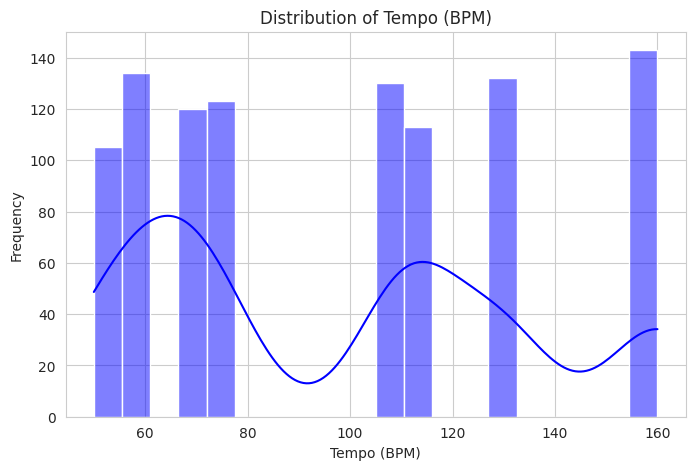

In [19]:
# 7. Tempo Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Tempo (BPM)"], bins=20, kde=True, color="blue")
plt.title("Distribution of Tempo (BPM)")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Frequency")
plt.show()

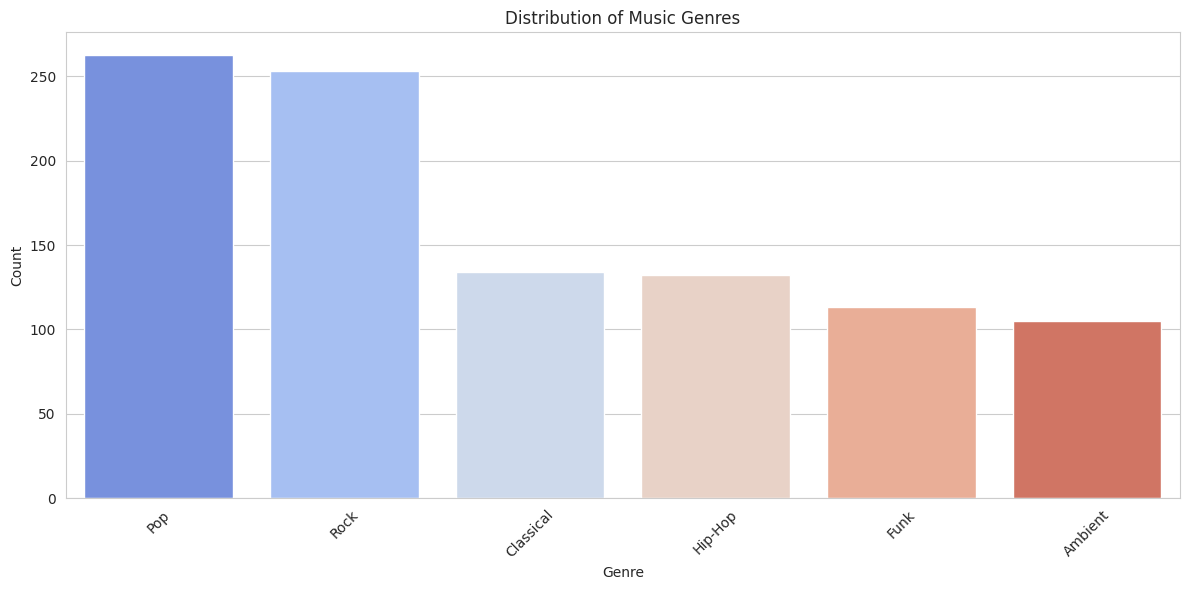

In [20]:
## Count Plot for Genre
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Genre', palette='coolwarm', order=df['Genre'].value_counts().index)
plt.title('Distribution of Music Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Predective Modeling

In [21]:
features = ['Tempo (BPM)', 'Genre', 'Mood', 'Energy', 'Danceability']
target = 'Sentiment_Label'

In [22]:
model_df = df[features + [target]].copy()

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Genre"] = le.fit_transform(df["Genre"]) 

In [24]:
categorical_features = ['Genre', 'Mood', 'Energy', 'Danceability']
model_df = pd.get_dummies(model_df, columns=categorical_features, drop_first=True)

## Train test splitting

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = model_df.drop(target, axis=1)
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
label_encoders = {}
for col in ["Genre", "Mood"]:  # Add other categorical columns if needed
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [29]:
target = "Sentiment_Label"
le_target = LabelEncoder()
df[target] = le_target.fit_transform(df[target])

In [30]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}


Model: Random Forest
              precision    recall  f1-score   support

       Happy       1.00      1.00      1.00        48
   Motivated       1.00      1.00      1.00        57
     Relaxed       1.00      1.00      1.00        44
         Sad       1.00      1.00      1.00        51

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Model: Logistic Regression
              precision    recall  f1-score   support

       Happy       1.00      1.00      1.00        48
   Motivated       1.00      1.00      1.00        57
     Relaxed       1.00      1.00      1.00        44
         Sad       1.00      1.00      1.00        51

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Model: SVM
              precision    recall  f1-score   support

       Happy 

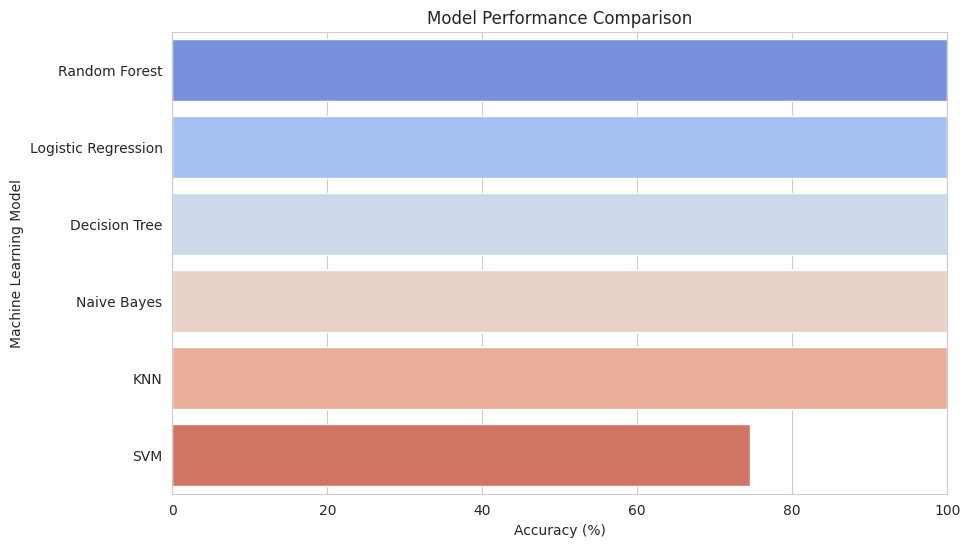

In [31]:
from sklearn.metrics import classification_report

# Train & evaluate models
accuracy_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_results[name] = accuracy * 100  # Convert to percentage

    # Print classification report
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))

# Convert results to a DataFrame
accuracy_df = pd.DataFrame(list(accuracy_results.items()), columns=["Model", "Accuracy"])
accuracy_df = accuracy_df.sort_values(by="Accuracy", ascending=False)

# Plot accuracy results
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model", data=accuracy_df, palette="coolwarm")
plt.xlabel("Accuracy (%)")
plt.ylabel("Machine Learning Model")
plt.title("Model Performance Comparison")
plt.xlim(0, 100)  # Accuracy is in percentage
plt.show()
